In [23]:
%load_ext autoreload
%autoreload 2

import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
from scipy.stats import spearmanr, pearsonr
from sklearn.cross_decomposition import CCA
from sklearn.preprocessing import StandardScaler
%matplotlib inline
# Add parent directory to path
notebook_dir = os.path.dirname(os.path.abspath(''))
if notebook_dir not in sys.path:
    sys.path.append(os.path.dirname(notebook_dir))

print(f"scanpy version: {sc.__version__}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
scanpy version: 1.11.5


/tmp/ipykernel_190602/188544676.py:18: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(f"scanpy version: {sc.__version__}")


In [2]:
MERFISH_DATA_DIR  = '/root/capsule/data/merfish_data/adata' # change this to where your adata_mer_subset_2_2k data is

In [27]:
MESH_DIR_sym = '/root/capsule/data/merfish_data/meshdata'  # change this to the OLD mesh location (this is where i get the midline of the hemispheares)

# load data!

In [28]:
def load_and_preprocess_data():
    """Load  MERFISH data, perform initial preprocessing""" # not laoding mesh for this
    
    # allmeshes = utils.load_mesh(MESH_DIR, nameconstrains = '*new_core*')
    # mesh = allmeshes['new_core_mesh']
    # mesh.vertices = mesh.vertices[:, [1,2, 0]]  # they somehow swapped the order -_-
    # mesh.vertices /= 25  # Scale vertices to mm
    
    print("Loading MERFISH data...")
    filename = os.path.join(MERFISH_DATA_DIR, 'adata_mer_subset_2_2k.h5ad')    
    adata_mer = sc.read_h5ad(filename)
    librarysize = np.sum(adata_mer.X, 1)
    normed_x = 1000*adata_mer.X/librarysize[:,None]
    adata_mer.X = normed_x

    # some removal of the ventral cell
    y = adata_mer.obsm["spatial"][:, 1]
    keep = y <= 220
    print(f"Removing {(~keep).sum()} cells with DV axis > 220")  # this shoudl show 41
    adata_mer = adata_mer[keep].copy()
    print(f"After filtering: {adata_mer.shape}")  # this should be 2221
    return _, _, adata_mer

_, _, adata_mer = load_and_preprocess_data()

Loading MERFISH data...
Removing 41 cells with DV axis > 220
After filtering: (2221, 315)


In [29]:

def load_sym_mesh(meshhome):
    """Load three mesh objects for LC, CD and CV."""
    import trimesh    
    mesh_LC = trimesh.load_mesh(meshhome+"/LC_ccf_v1_250102 2.obj")
    mesh_CD = trimesh.load_mesh(meshhome+"/subCD_ccf_v1_250102 2.obj")
    mesh_CV = trimesh.load_mesh(meshhome+"/subCV_ccf_v1_250102 2.obj")
    allmeshes = [mesh_LC,mesh_CD,mesh_CV]
    return allmeshes

def flip(a, xm):
        return(2*xm-a)

def get_hemi(S_mer, meshhome=None):
    '''assume the axis of interest are both on the last axis. '''
    if meshhome !=None:
        allmeshes = load_sym_mesh(meshhome)
        mesh = allmeshes[-1]
    xm = np.min(mesh.vertices[:,-1]) + np.ptp(mesh.vertices[:,-1])/2 # this is the center line to indicate the hemisphere 
    new_coords = S_mer.copy()
    new_coords[:,-1] = np.where(new_coords[:,-1] > xm, flip(new_coords[:,-1],xm), new_coords[:,-1])    
    return(new_coords)


In [30]:

def perform_cca(X, S, n_components=2, scl_multiplier=25):
    """   Perform Canonical Correlation Analysis between gene expression and spatial data
    inputs::::
    X : numpy.ndarray
        Gene expression matrix
    S : numpy.ndarray
        Spatial coordinates
    n_components : int, default=2
        Number of components for CCA
    scl_multiplier : float, default=25
        Scaling factor for spatial coordinates
    
    outputs::::
    cca : CCA object
        Fitted CCA model
    X_c : numpy.ndarray
        Transformed gene expression data
    S_c : numpy.ndarray
        Transformed spatial data
    canonical_correlations : list
        List of canonical correlations"""
    scaler_X = StandardScaler().fit(X)
    X_scaled = scaler_X.transform(X)
    scaler_S = StandardScaler().fit(S * scl_multiplier)
    S_scaled = scaler_S.transform(S)
    cca = CCA(n_components=n_components)
    cca.fit(X_scaled, S_scaled)
    X_c, S_c = cca.transform(X_scaled, S_scaled)
    canonical_correlations = [np.corrcoef(X_c[:, i], S_c[:, i])[0, 1] for i in range(n_components)]
    return cca, X_c, S_c, canonical_correlations 


In [31]:
scl_multiplier = 25  # this corresponds to the resolutions
def perform_cca_analysis(adata_mer, n_components=2, scl_multiplier=scl_multiplier):
    """Perform CCA analysis between gene expression and spatial coordinates"""
    S_mer_fo_cca = get_hemi(adata_mer.obsm['spatial'], MESH_DIR_sym)

    gene_input = adata_mer.X # sample x gene
    coords_input = S_mer_fo_cca # smaple x 3
    
    cca, X_c, S_c, canonical_correlations = perform_cca(
        X=gene_input,
        S = coords_input, 
        n_components=n_components, 
        scl_multiplier=scl_multiplier)    
    print(f"Canonical correlations: {canonical_correlations}")
    return cca, X_c, S_c, canonical_correlations

In [32]:
coords = adata_mer.obsm['spatial']
gene = adata_mer.X

In [33]:

cca, X_c, S_c, canonical_correlations = perform_cca_analysis(adata_mer)

Canonical correlations: [np.float64(0.7838868631959646), np.float64(0.598294311555284)]


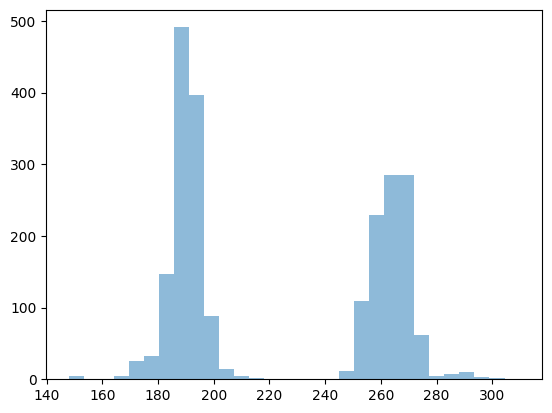

In [34]:
plt.hist(coords[:, 2], bins=30, alpha=0.5, label='X-axis')
plt.show()

In [35]:
cca.y_weights_[:,0] # for the arrow cca.y_weights_[:, k] is what you want from here. (k=0) - the unit vecrtor on AP, DV and ML axis. 

array([-0.49815938,  0.83441557, -0.23577085])